In [10]:
import torch

In [11]:
n_size = 25

In [12]:
import numpy as np

In [13]:
def create_data(samples, classes):
    X = np.zeros((samples*classes, 2))
    y = np.zeros(samples*classes, dtype='uint8')
    for class_number in range(classes):
        ix = range(samples*class_number, samples*(class_number+1))
        r = np.linspace(0.0, 1, samples)
        t = np.linspace(class_number*4, (class_number+1)*4, samples) + np.random.randn(samples)*0.2
        X[ix] = np.c_[r*np.sin(t*2.5), r*np.cos(t*2.5)]
        y[ix] = class_number
    return X, y


In [26]:
from sklearn.datasets import make_circles
n_samples = n_size  # Number of data points
noise_level = 0.05 # Add some noise for a more realistic scenario
factor_inner = 0.5 # Scale factor between inner and outer circle

spiral_X, spiral_y = create_data(samples=n_samples, classes=2)
spiral_X = torch.from_numpy(spiral_X).float()
spiral_y = torch.from_numpy(spiral_y)

In [15]:
simple_X = torch.randn(size=(n_samples, 2), dtype=torch.float)
simple_y = torch.randint(0, 2, (n_samples,))

In [16]:
import torch.nn as nn
import torch.nn.functional as F

In [27]:
learning_rate = 0.01
momentum = 0.1
batch_size = 10
l2_decay = 0.001
max_steps = 1000000

In [33]:
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.Tanh(),
    nn.Linear(16, 2),
    nn.Tanh()
    )

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=l2_decay)



In [34]:
model.train()
for step in range(max_steps):
    model.zero_grad()
    logits = model(spiral_X)
    loss = F.cross_entropy(logits, spiral_y)
    loss.backward()
    optimizer.step()
    if (step % 100000 == 0):
        print(f'step {step}, loss: {loss.item():.6f}')



step 0, loss: 0.702638
step 100000, loss: 0.534522
step 200000, loss: 0.489584
step 300000, loss: 0.477844
step 400000, loss: 0.473622
step 500000, loss: 0.469692
step 600000, loss: 0.462630
step 700000, loss: 0.458525
step 800000, loss: 0.457231
step 900000, loss: 0.456998


In [35]:
model.eval()

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): Tanh()
  (2): Linear(in_features=16, out_features=2, bias=True)
  (3): Tanh()
)

In [21]:
import matplotlib.pyplot as plt

In [22]:
import numpy as np

In [23]:
def predict(x):
 #Convert into numpy element to tensor
 x = torch.from_numpy(x).type(torch.FloatTensor)
 #Predict and return ans
 ans = model(x)
 ans = torch.argmax(F.softmax(ans, dim=-1), dim=-1)
 return ans.detach().numpy()

In [24]:
def plot_decision_boundary(X,y):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy=np.meshgrid(torch.arange(x_min, x_max, h), torch.arange(y_min, y_max, h))
    # Predict the function value for the whole gid
    Z = predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

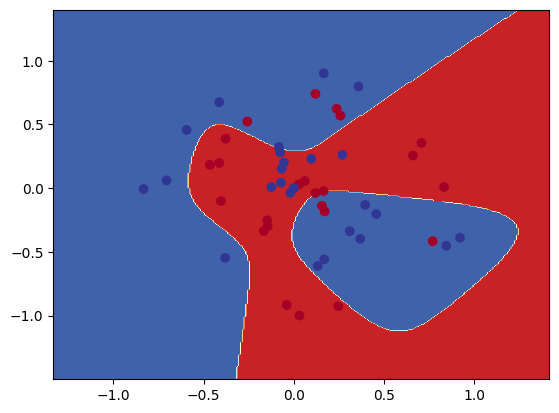

In [36]:
plot_decision_boundary(spiral_X.numpy(), spiral_y.numpy())
